First 5 Rows
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24,

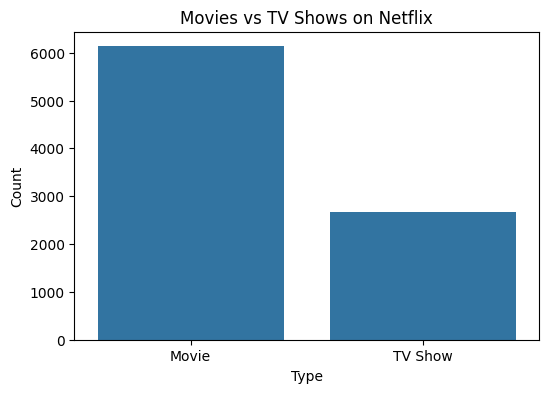

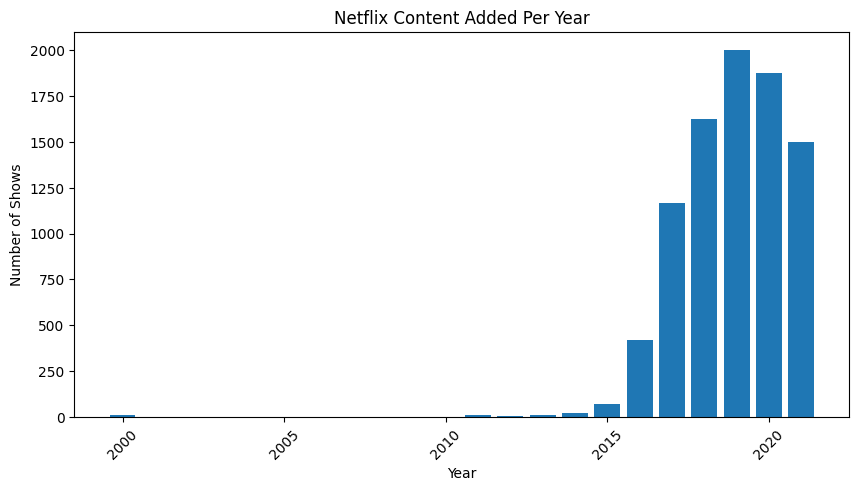

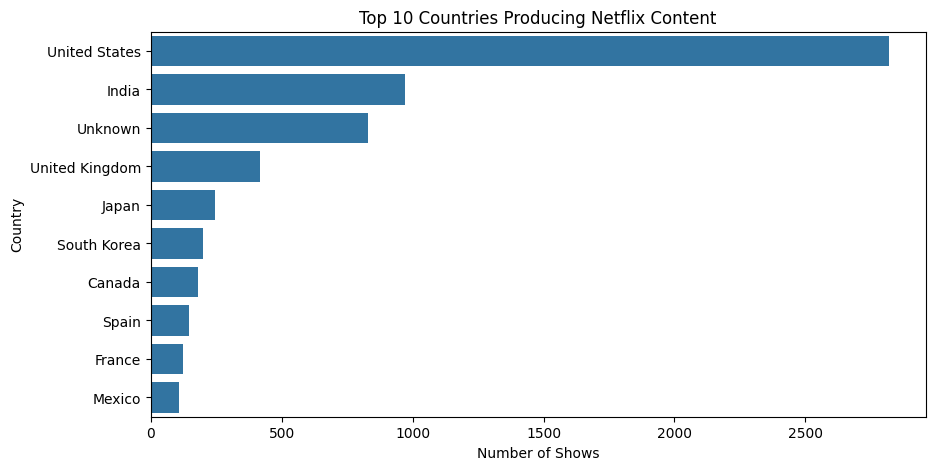

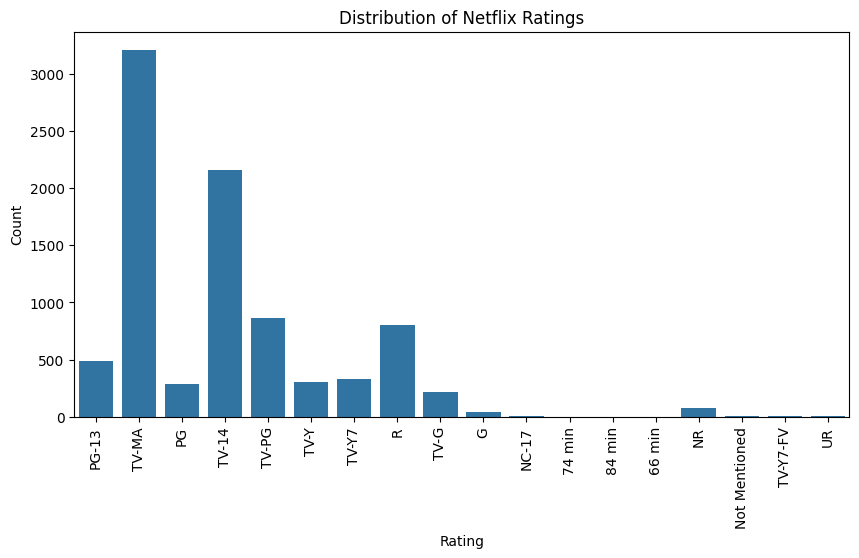

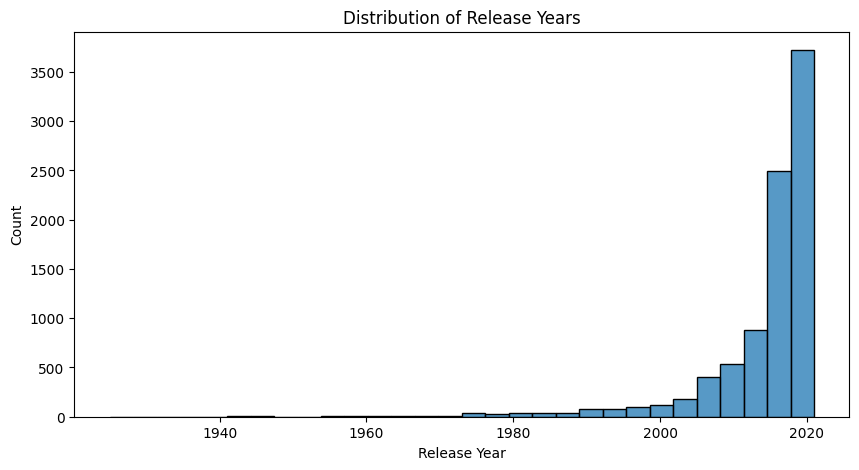

In [31]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/kaggle/input/datasets/amansatyam18/netfix-movies-and-shows/netflix_titles.csv")

# Basic Data Exploration
print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nTotal Values")
print(df.size)

print("\nDataset Description")
print(df.describe())

print("\nMissing Values Before Cleaning")
print(df.isnull().sum())


# Data Cleaning
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("No Cast Listed")
df["country"] = df["country"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Not Mentioned")
df["rating"] = df["rating"].fillna("Not Mentioned")

# Fix date column
df["date_added"] = df["date_added"].fillna("January 1, 2000")
df["date_added"] = pd.to_datetime(df["date_added"],errors="coerce")

# Create new column
df["year_added"] = df["date_added"].dt.year


print("\nMissing Values After Cleaning")
print(df.isnull().sum())


# Visualization 1: Movies vs TV Shows
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()


# Visualization 2: Content Added Per Year
year_counts = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(year_counts.index, year_counts.values)

plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Shows")

plt.xticks(rotation=45)

plt.show()



# Visualization 3: Top 10 Countries
top_countries = df["country"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Shows")
plt.ylabel("Country")
plt.show()


# Visualization 4: Rating Distribution
plt.figure(figsize=(10,5))
sns.countplot(x="rating", data=df)

plt.title("Distribution of Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()


# Visualization 5: Release Year Distribution
plt.figure(figsize=(10,5))
sns.histplot(df["release_year"], bins=30)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.show()